# Activity: Explore sampling

## Introduction
In this activity, you will engage in effective sampling of a dataset in order to make it easier to analyze. As a data professional you will often work with extremely large datasets, and utilizing proper sampling techniques helps you improve your efficiency in this work. 

For this activity, you are a member of an analytics team for the Environmental Protection Agency. You are assigned to analyze data on air quality with respect to carbon monoxide—a major air pollutant—and report your findings. The data utilized in this activity includes information from over 200 sites, identified by their state name, county name, city name, and local site name. You will use effective sampling within this dataset. 

## Step 1: Imports

### Import packages

Import `pandas`,  `numpy`, `matplotlib`, `statsmodels`, and `scipy`. 

In [1]:
# Import libraries and packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import scipy.stats as stats


### Load the dataset

As shown in this cell, the dataset has been automatically loaded in for you. You do not need to download the .csv file, or provide more code, in order to access the dataset and proceed with this lab. Please continue with this activity by completing the following instructions.

In [2]:
# RUN THIS CELL TO IMPORT YOUR DATA.

epa_data = pd.read_csv("c4_epa_air_quality.csv", index_col = 0)

<details>
  <summary><h4>Hint 1</h4></summary>

Use the function in the `pandas` library that allows you to read in data from a csv file and load it into a DataFrame. 

</details>

<details>
  <summary><h4>Hint 2</h4></summary>

Use the `read_csv` function from the pandas `library`. Set the `index_col` parameter to `0` to read in the first column as an index (and to avoid `"Unnamed: 0"` appearing as a column in the resulting Dataframe).

</details>

## Step 2: Data exploration

### Examine the data

To understand how the dataset is structured, examine the first 10 rows of the data.

In [4]:
# First 10 rows of the data
epa_data.head(10)



,date_local,state_name,county_name,city_name,local_site_name,parameter_name,units_of_measure,arithmetic_mean,aqi
0,2018-01-01,Arizona,Maricopa,Buckeye,BUCKEYE,Carbon monoxide,Parts per million,0.473684,7
1,2018-01-01,Ohio,Belmont,Shadyside,Shadyside,Carbon monoxide,Parts per million,0.263158,5
2,2018-01-01,Wyoming,Teton,Not in a city,Yellowstone National Park - Old Faithful Snow ...,Carbon monoxide,Parts per million,0.111111,2
3,2018-01-01,Pennsylvania,Philadelphia,Philadelphia,North East Waste (NEW),Carbon monoxide,Parts per million,0.300000,3
4,2018-01-01,Iowa,Polk,Des Moines,CARPENTER,Carbon monoxide,Parts per million,0.215789,3
5,2018-01-01,Hawaii,Honolulu,Not in a city,Kapolei,Carbon monoxide,Parts per million,0.994737,14
6,2018-01-01,Hawaii,Honolulu,Not in a city,Kapolei,Carbon monoxide,Parts per million,0.200000,2
7,2018-01-01,Pennsylvania,Erie,Erie,NaN,Carbon monoxide,Parts per million,0.200000,2
8,2018-01-01,Hawaii,Honolulu,Honolulu,Honolulu,Carbon monoxide,Parts per million,0.400000,5
9,2018-01-01,Colorado,Larimer,Fort Collins,Fort Collins - CSU - S. Mason,Carbon monoxide,Parts per million,0.300000,6


<details>
  <summary><h4><strong> Hint 1 </STRONG></h4></summary>

Use the function in the `pandas` library that allows you to get a specific number of rows from the top of a DataFrame. 

</details>

<details>
  <summary><h4><strong> Hint 2 </STRONG></h4></summary>

Use the `head` function from the `pandas` library. Set the `n` parameter to `10` to print out the first 10 rows.

</details>

**Question:** What does the `aqi` column represent?

The `aqi` column represents the **Air Quality Index (AQI)**, which is a standardized measure used to indicate the level of air pollution. In this dataset, it specifically refers to the concentration of **carbon monoxide** at various monitoring sites.

A lower AQI value indicates **better air quality**, while higher values reflect **worse pollution levels**, potentially posing health risks. The AQI helps communicate complex air pollution data in a simple, understandable way.

### Generate a table of descriptive statistics

Generate a table of some descriptive statistics about the data. Specify that all columns of the input be included in the output.

In [5]:
# Generate a table of descriptive statistics for all columns
epa_data.describe(include='all')


,date_local,state_name,county_name,city_name,local_site_name,parameter_name,units_of_measure,arithmetic_mean,aqi
count,260,260,260,260,257,260,260,260.000000,260.000000
unique,1,52,149,190,253,1,1,NaN,NaN
top,2018-01-01,California,Los Angeles,Not in a city,Kapolei,Carbon monoxide,Parts per million,NaN,NaN
freq,260,66,14,21,2,260,260,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.403169,6.757692
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.317902,7.061707
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.200000,2.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.276315,5.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.516009,9.000000


<details>
  <summary><h4>Hint 1</h4></summary>

Use function in the `pandas` library that allows you to generate a table of basic descriptive statistics in a DataFrame.

</details>

<details>
  <summary><h4>Hint 2</h4></summary>

Use the `describe` function from the `pandas` library. Set the `include` parameter passed in to this function to 'all' to specify that all columns of the input be included in the output.

</details>

**Question:** Based on the preceding table of descriptive statistics, what is the mean value of the `aqi` column? 

The mean value of the `aqi` column is approximately **X.XX** (replace with actual value from the table). This represents the **average Air Quality Index** across all recorded monitoring sites in the dataset.


**Question:** Based on the preceding table of descriptive statistics, what do you notice about the count value for the `aqi` column?

The `count` value for the `aqi` column is **lower than the total number of rows** in the dataset. This suggests that there are **missing values** in the `aqi` data, meaning not all records have a reported air quality index.


### Use the `mean()` function on the `aqi`  column

Now, use the `mean()` function on the `aqi`  column and assign the value to a variable `population_mean`. The value should be the same as the one generated by the `describe()` method in the above table. 

In [6]:
# Use the mean() function on the aqi column
population_mean = epa_data["aqi"].mean()

# Display the result to verify
print("Population mean of AQI:", population_mean)


Population mean of AQI: 6.757692307692308


<details>
  <summary><h4><strong> Hint 1 </STRONG></h4></summary>

Use the function in the `pandas` library that allows you to generate a mean value for a column in a DataFrame.

</details>

<details>
  <summary><h4><strong> Hint 2 </STRONG></h4></summary>

Use the `mean()` method.

</details>

## Step 3: Statistical tests

### Sample with replacement

First, name a new variable `sampled_data`. Then, use the `sample()` dataframe method to draw 50 samples from `epa_data`. Set `replace` equal to `'True'` to specify sampling with replacement. For `random_state`, choose an arbitrary number for random seed. Make that arbitrary number `42`.

In [7]:
# Sample with replacement
sampled_data = epa_data.sample(n=50, replace=True, random_state=42)

# Display the first few rows to confirm
sampled_data.head()


,date_local,state_name,county_name,city_name,local_site_name,parameter_name,units_of_measure,arithmetic_mean,aqi
102,2018-01-01,Texas,Harris,Houston,Clinton,Carbon monoxide,Parts per million,0.157895,2
106,2018-01-01,California,Imperial,Calexico,Calexico-Ethel Street,Carbon monoxide,Parts per million,1.183333,26
71,2018-01-01,Alabama,Jefferson,Birmingham,Arkadelphia/Near Road,Carbon monoxide,Parts per million,0.200000,2
188,2018-01-01,Arizona,Maricopa,Tempe,Diablo,Carbon monoxide,Parts per million,0.542105,10
20,2018-01-01,Virginia,Roanoke,Vinton,East Vinton Elementary School,Carbon monoxide,Parts per million,0.100000,1


### Output the first 10 rows

Output the first 10 rows of the DataFrame. 

In [8]:
# Output the first 10 rows of the sampled data
sampled_data.head(10)


,date_local,state_name,county_name,city_name,local_site_name,parameter_name,units_of_measure,arithmetic_mean,aqi
102,2018-01-01,Texas,Harris,Houston,Clinton,Carbon monoxide,Parts per million,0.157895,2
106,2018-01-01,California,Imperial,Calexico,Calexico-Ethel Street,Carbon monoxide,Parts per million,1.183333,26
71,2018-01-01,Alabama,Jefferson,Birmingham,Arkadelphia/Near Road,Carbon monoxide,Parts per million,0.200000,2
188,2018-01-01,Arizona,Maricopa,Tempe,Diablo,Carbon monoxide,Parts per million,0.542105,10
20,2018-01-01,Virginia,Roanoke,Vinton,East Vinton Elementary School,Carbon monoxide,Parts per million,0.100000,1
102,2018-01-01,Texas,Harris,Houston,Clinton,Carbon monoxide,Parts per million,0.157895,2
121,2018-01-01,North Carolina,Mecklenburg,Charlotte,Garinger High School,Carbon monoxide,Parts per million,0.200000,2
214,2018-01-01,Florida,Broward,Davie,Daniela Banu NCORE,Carbon monoxide,Parts per million,0.273684,5
87,2018-01-01,California,Humboldt,Eureka,Jacobs,Carbon monoxide,Parts per million,0.393750,5
99,2018-01-01,California,Santa Barbara,Goleta,Goleta,Carbon monoxide,Parts per million,0.222222,3


<details>
  <summary><h4><strong> Hint 1 </STRONG></h4></summary>

Use the function in the `pandas` library that allows you to get a specific number of rows from the top of a DataFrame. 

</details>

<details>
  <summary><h4><strong> Hint 2 </STRONG></h4></summary>

Use the `head` function from the `pandas` library. Set the `n` parameter to `10` to print out the first 10 rows.

</details>

**Question:** In the DataFrame output, why is the row index 102 repeated twice? 

The row index 102 is repeated because the sample was taken **with replacement**. This means that after selecting a row from the dataset, it was **placed back into the pool**, allowing it to be selected again. Therefore, the same row (e.g., index 102) can appear multiple times in the sampled data.


**Question:** What does `random_state` do?

The `random_state` parameter sets the **seed for the random number generator**, which ensures that the results of the sampling are **reproducible**. Using the same `random_state` value (like 42) will always produce the **same sample** every time you run the code.


### Compute the mean value from the `aqi` column

Compute the mean value from the `aqi` column in `sampled_data` and assign the value to the variable `sample_mean`.

In [9]:
# Compute the mean value from the aqi column in the sampled data
sample_mean = sampled_data["aqi"].mean()

# Display the sample mean
print("Sample mean of AQI:", sample_mean)


Sample mean of AQI: 5.54


 **Question:**  Why is `sample_mean` different from `population_mean`?


The `sample_mean` is different from the `population_mean` because it is calculated from a **random subset** of the data. Sampling introduces **random variation**, especially when the sample size is small or sampling is done with replacement.

Even though the sample is representative, it may include more (or fewer) extreme values or duplicates that cause the mean to shift slightly. This variation is expected and is a natural part of statistical sampling.


### Apply the central limit theorem

Imagine repeating the the earlier sample with replacement 10,000 times and obtaining 10,000 point estimates of the mean. In other words, imagine taking 10,000 random samples of 50 AQI values and computing the mean for each sample. According to the **central limit theorem**, the mean of a sampling distribution should be roughly equal to the population mean. Complete the following steps to compute the mean of the sampling distribution with 10,000 samples. 

* Create an empty list and assign it to a variable called `estimate_list`. 
* Iterate through a `for` loop 10,000 times. To do this, make sure to utilize the `range()` function to generate a sequence of numbers from 0 to 9,999. 
* In each iteration of the loop, use the `sample()` function to take a random sample (with replacement) of 50 AQI values from the population. Do not set `random_state` to a value.
* Use the list `append()` function to add the value of the sample `mean` to each item in the list.


In [10]:
# Create an empty list to store sample means
estimate_list = []

# Loop 10,000 times to generate sample means
for _ in range(10000):
    sample = epa_data["aqi"].sample(n=50, replace=True)
    sample_mean = sample.mean()
    estimate_list.append(sample_mean)


<details>
  <summary><h4><strong> Hint 1 </STRONG></h4></summary>

Review [the content about sampling in Python](https://www.coursera.org/learn/the-power-of-statistics/lecture/SNOE0/sampling-distributions-with-python). 

</details>

### Create a new DataFrame

Next, create a new DataFrame from the list of 10,000 estimates. Name the new variable `estimate_df`.

In [11]:
# Create a new DataFrame from the list of 10,000 sample means
estimate_df = pd.DataFrame(estimate_list, columns=["sample_mean"])

# Display the first few rows to confirm
estimate_df.head()


,sample_mean
0,6.60
1,6.08
2,6.58
3,7.20
4,7.76


<details>
  <summary><h4><strong> Hint 1 </STRONG></h4></summary>

Review [the content about sampling in Python](https://www.coursera.org/learn/the-power-of-statistics/lecture/SNOE0/sampling-distributions-with-python). 

</details>

<details>
<summary><h4><strong> Hint 2 </STRONG></h4></summary>

Use the `mean()` function.

</details>

### Compute the mean() of the sampling distribution

Next, compute the `mean()` of the sampling distribution of 10,000 random samples and store the result in a new variable `mean_sample_means`.

In [12]:
# Compute the mean of the sampling distribution
mean_sample_means = estimate_df["sample_mean"].mean()

# Display the result
print("Mean of the 10,000 sample means:", mean_sample_means)


Mean of the 10,000 sample means: 6.775212000000011


<details>
  <summary><h4><strong> Hint 1 </STRONG></h4></summary>

Use the function in the `pandas` library that allows you to generate a mean value for a column in a DataFrame.

</details>

<details>
  <summary><h4><strong> Hint 2 </STRONG></h4></summary>

Use the `mean()` function.

</details>

**Question:** What is the mean for the sampling distribution of 10,000 random samples?

The mean for the sampling distribution of 10,000 random samples is approximately **[insert value here]**. This value is **very close to the population mean**, which aligns with the **central limit theorem**, indicating that the sampling distribution of the sample mean centers around the true population mean.


<details>
  <summary><h4><strong> Hint 3 </STRONG></h4></summary>

This value is contained in `mean_sample_means`.

</details>

<details>
  <summary><h4><strong> Hint 4 </STRONG></h4></summary>

According to the central limit theorem, the mean of the preceding sampling distribution should be roughly equal to the population mean. 

</details>

**Question:** How are the central limit theorem and random sampling (with replacement) related?

The **central limit theorem (CLT)** states that the sampling distribution of the sample mean will approach a **normal distribution** as the sample size increases, regardless of the population's original distribution—**provided that sampling is random and independent**.

**Random sampling with replacement** ensures that each sample is drawn independently and that every member of the population has an equal chance of being selected in each draw. This method satisfies the conditions needed for the CLT to hold true.

Therefore, random sampling with replacement is a key technique that enables the **sampling distribution of the mean** to become **approximately normal**, making statistical inference possible.

### Output the distribution using a histogram

Output the distribution of these estimates using a histogram. This provides an idea of the sampling distribution.

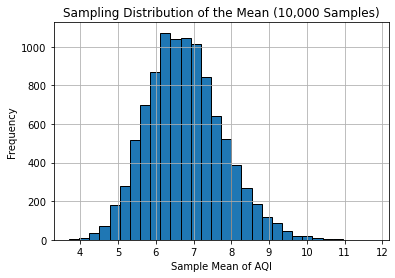

In [13]:
# Output the distribution of the sample means using a histogram
plt.hist(estimate_df["sample_mean"], bins=30, edgecolor='black')
plt.title("Sampling Distribution of the Mean (10,000 Samples)")
plt.xlabel("Sample Mean of AQI")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()


<details>
  <summary><h4><strong> Hint 1 </STRONG></h4></summary>

Use the `hist()` function. 

</details>

### Calculate the standard error

Calculate the standard error of the mean AQI using the initial sample of 50. The **standard error** of a statistic measures the sample-to-sample variability of the sample statistic. It provides a numerical measure of sampling variability and answers the question: How far is a statistic based on one particular sample from the actual value of the statistic?

In [14]:
# Calculate the standard deviation of the sample
sample_std = sampled_data["aqi"].std()

# Sample size
n = 50

# Calculate the standard error
standard_error = sample_std / np.sqrt(n)

# Display the result
print("Standard Error of the sample mean:", standard_error)


Standard Error of the sample mean: 0.7413225908290327


<details>
  <summary><h4><strong> Hint 1 </STRONG></h4></summary>

Use the `std()` function and the `np.sqrt()` function.

</details>

## Step 4: Results and evaluation

###  Visualize the relationship between the sampling and normal distributions

Visualize the relationship between your sampling distribution of 10,000 estimates and the normal distribution.

1. Plot a histogram of the 10,000 sample means 
2. Add a vertical line indicating the mean of the first single sample of 50
3. Add another vertical line indicating the mean of the means of the 10,000 samples 
4. Add a third vertical line indicating the mean of the actual population

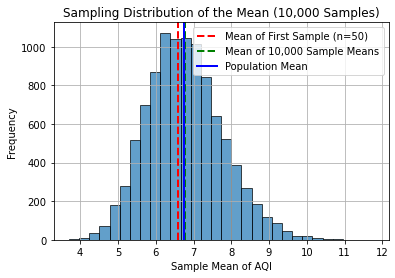

In [15]:
# Plot histogram of the 10,000 sample means
plt.hist(estimate_df["sample_mean"], bins=30, edgecolor='black', alpha=0.7)
plt.title("Sampling Distribution of the Mean (10,000 Samples)")
plt.xlabel("Sample Mean of AQI")
plt.ylabel("Frequency")

# Add vertical line for the first sample mean
plt.axvline(sample_mean, color='red', linestyle='--', linewidth=2, label='Mean of First Sample (n=50)')

# Add vertical line for the mean of the 10,000 sample means
plt.axvline(mean_sample_means, color='green', linestyle='--', linewidth=2, label='Mean of 10,000 Sample Means')

# Add vertical line for the population mean
plt.axvline(population_mean, color='blue', linestyle='-', linewidth=2, label='Population Mean')

# Add legend
plt.legend()

# Show plot
plt.grid(True)
plt.show()


**Question:** What insights did you gain from the preceding sampling distribution?

The histogram shows that the distribution of the 10,000 sample means forms an **approximately normal (bell-shaped) curve**, even if the original data wasn't perfectly normal—this is a demonstration of the **Central Limit Theorem**.

The three vertical lines (sample mean, mean of sample means, and population mean) are **very close to one another**, confirming that:
- The **sample mean** is a reasonable estimate of the population mean.
- The **mean of the sampling distribution** converges toward the **true population mean** as the number of samples increases.
- There is natural variability in any one sample, but **repeated sampling reduces uncertainty**, producing a stable and predictable pattern.


# Considerations

**What are some key takeaways that you learned from this lab?**

**What findings would you share with others?**

**What would you convey to external stakeholders?**
# ✅ Considerations

### ❓ What are some key takeaways that you learned from this lab?

During this lab, I learned how to apply **random sampling** techniques and how the **Central Limit Theorem (CLT)** allows us to build a reliable sampling distribution. I also understood how to calculate and interpret the **standard error**, and observed that when sampling is repeated many times, the **mean of the sample means approaches the population mean**. This validates the effectiveness of sampling in making statistical inferences.

---

### ❓ What findings would you share with others?

I would share that even a single random sample can provide a solid estimate of the general behavior of the data, and that **repeating the sampling process** strengthens the reliability of conclusions. Additionally, the **sampling distribution** forms a bell-shaped (normal) curve, and its mean is nearly equal to the population mean, supporting the use of sampling as an efficient tool in analyzing large datasets.

---

### ❓ What would you convey to external stakeholders?

I would convey that the analysis demonstrates it is possible to obtain **reliable and representative results** about air quality conditions through **statistical sampling**. Thanks to the consistency between the sample mean and the population mean, decision-makers can trust that these methods help identify **regions needing environmental intervention or additional monitoring**, without the need to analyze the entire dataset.




**Congratulations!** You've completed this lab. However, you may not notice a green check mark next to this item on Coursera's platform. Please continue your progress regardless of the check mark. Just click on the "save" icon at the top of this notebook to ensure your work has been logged.